El presente proyecto tiene como finalidad documentar el proceso de construcción de un modelo de predicción catalogado dentro de las técnicas de aprendizaje automático como clasificación.

Dicha clasificación se pretende obtener a través de un modelo de regresión logística.

El set de datos a trabajar es el denominado "IBM HR Analytics Employee Attrition & Performance" alojado en https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Dicho data set pretende abarcar el problema de rotación de personal dentro de la empresa IBM en EE.UU. Como se ha mencionado, a través de un modelo de regresión se pretende clasificar a aquellos colaboradores propensos a renunciar, además de explorar las probables causas de renuncia.

**Fase Entendimiento de Variables**

***Variables***



**1. Variable Objetivo (Target)**

**Attrition:** Indica si el empleado renunció o no (Yes/No). Es la variable que vamos a predecir.

-----------------------------

**2. Variables Demográficas y Personales**

**Age:** Edad del empleado (Numérica).

**Gender:** Género del empleado (Female/Male).

**MaritalStatus:** Estado civil (Single, Married, Divorced).

**Education:** Nivel académico del 1 al 5 (1: Debajo de Universidad, 2: Universidad, 3: Licenciatura, 4: Maestría, 5: Doctorado).

**EducationField:** Área de estudio (Ej. Ciencias de la Vida, Marketing, Medicina, etc.).

**DistanceFromHome:** Distancia en kilómetros entre el hogar y el trabajo.

**NumCompaniesWorked:** Número de empresas en las que el empleado ha trabajado antes de IBM.

--------------------------------

**3. Variables de Desempeño y Carga Laboral**

**OverTime:** Indica si el empleado trabaja horas extra (Yes/No).

**BusinessTravel:** Frecuencia de viajes de negocios (Non-Travel, Travel_Rarely, Travel_Frequently).

**TrainingTimesLastYear:** Número de capacitaciones que el empleado tomó el año pasado.

**PerformanceRating:** Calificación de desempeño del último año (3: Excelente, 4: Sobresaliente).

**StandardHours:** Horas estándar de trabajo.

--------------------------------

**4. Variables de Compensación y Estatus**

**MonthlyIncome:** Salario mensual bruto.

**DailyRate / HourlyRate / MonthlyRate:** Tarifas de pago calculadas en diferentes unidades de tiempo.

**PercentSalaryHike:** Porcentaje de aumento salarial en el último periodo.

**StockOptionLevel:** Nivel de opciones sobre acciones otorgadas al empleado (0 a 3).

**JobLevel:** Nivel jerárquico en la organización (1 al 5).

**JobRole:** Puesto o rol específico (Ej. Sales Executive, Manager, Manufacturing Director).

**Department:** Departamento al que pertenece (Sales, R&D, Human Resources).

---------------------------------------

**5. Variables de Antigüedad y Estabilidad**

**TotalWorkingYears:** Total de años de experiencia laboral del empleado.

**YearsAtCompany:** Años laborando específicamente en la compañía actual.

**YearsInCurrentRole:** Años que lleva desempeñando su puesto actual.

**YearsSinceLastPromotion:** Años transcurridos desde su último ascenso.

**YearsWithCurrManager:** Años trabajando bajo la supervisión de su jefe actual.

---------------------------------------

**6. Variables de Satisfacción y Percepción (Escala 1-4)**

**EnvironmentSatisfaction:** Satisfacción con el entorno de trabajo.

**JobInvolvement:** Nivel de involucramiento o compromiso con sus tareas.

**JobSatisfaction:** Nivel de satisfacción con el trabajo realizado.

**RelationshipSatisfaction:** Calidad de las relaciones con sus compañeros.

**WorkLifeBalance:** Equilibrio percibido entre la vida personal y profesional.

------------------------------------

**7. Variables Administrativas (A eliminar)**

**EmployeeCount:** Sin descripción.

**EmployeeNumber:** Identificador único (ID) del empleado.

**Over18:** Indica si es mayor de 18 años (Siempre "Y").

In [1]:
# Importando librería base para manipulación y visualización de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#conectando con repositorio local dónde se aloja el data set:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# importando dataset
data = pd.read_csv("/content/drive/MyDrive/Materias ISEC/Analítica de datos/WA_Fn-UseC_-HR-Employee-Attrition (1).csv")

#se carga una muestra del data set para confirmar su correcta importación:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


***Fase: Análisis esploratorio de datos (EDA)**

En esta primer fase se comenzarán a explorar las variables para detectar aquellas que pudieras ser irrelevantes y candidatas a eliminar, posteriormente se verificará la completitud y calidad de los datos, para finalmente verificar las distribuciones de las variables e identificar aquellas que requerirán algún tratamiento de tranformación

In [4]:
# para ver variables completas y estadísticas básicas a través del método describe.
# Nota: Se incluye el argumento "all" para poder visualizar todas las variables, no solo las numéricas

data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


**Observaciones iniciales**

**1. Variables a Eliminar en primera instancia**

Mirando las columnas std (desviación estándar) y unique, podemos validar las que deben irse:

**EmployeeCount:** mean es 1.0 y std es 0.0. No tiene variabilidad, por lo que no aporta información al modelo. Ingresarlo a este probablemente solo causaría ruido.

**Over18:** unique es 1 y el top es "Y". Todos son adultos, por lo que aporta la misma información para todas las observaciones.

**StandardHours:** mean, min y max tienen un valor de 80.0, además de tener std de 0.0. Es una constante también, por lo que no aporta variabilidad al modelo.

**EmployeeNumber:** Si bien dicha variable tiene amplia variabilidad, ésta no aporta información valiosa, ya que no es una caracteristica del colaborador, sino un identificador único que otorga el sistema al integrarse a la organización.

-----------------------------------------

**2. Primer acercamiento al Target (Attrition)**

Se tiene un conteo de 1470 observaciones

**unique** 2.

**top** "No" con freq 1233.

A primera vista se nota un desbalance de clases fuerte. Esta situación será tratada más adelante con la finalidad de que el modelo no memorice una clase y no deje de aprender de la otra.

-----------------------------------------

**3. Insights interesantes para el EDA (Fase 2)**

**MonthlyIncome:** Es importante notar la diferencia de escalas en algunas variables numéricas como esta, dónde se cuenta con valores entre 1,009(min) y 19,999(el max). El promedio (mean) está en 6,502, pero el $75\%$ de la gente gana menos de 8,379. Esto sugiere una distribución sesgada a la derecha (poca gente gana muchísimo), algo típico en salarios que la Regresión Logística sentirá.

**YearsAtCompany:** El max es 40 años, pero la mediana (50%) es apenas 5 años. ¡Hay mucha gente nueva!

Desde aquí se puede intuir que será necesario escalar las variables numéricas con la finalidad de que el modelo no les de más peso a algunas variables que a otras.

In [5]:
# para verificar la completitud de los datos:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Ahora que se conoce la completitud del dataset, se procede a eliminar las variables antes mencionadas:

variables_a_eliminar = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Eliminando variables
data.drop(columns=variables_a_eliminar, inplace=True)

# Verificando la nueva dimensión del dataset
print(f"La dimensión del data set es de {data.shape[0]} filas y {data.shape[1]} columnas.")


La dimensión del data set es de 1470 filas y 31 columnas.


In [7]:
# Durante el EDA se llevará acabo análisis de correlación de la variable  target contra las demás variables.
# para esto será necesario transformar los valores de la variable target. Aunque en esencia, ésta seguira siendo binaria.

data["Attrition"] = data["Attrition"].map({"Yes":1, "No": 0}) # reescribiendo las clases
# Conteo por clase para Attrition.
print(data["Attrition"].value_counts())


Attrition
0    1233
1     237
Name: count, dtype: int64


In [8]:
# para conocer la distribución porcentual de cada clase
# de esta manera es posible irme dando cuenta que tratamiento se hará sobre la variable para equilibrar el desbalance.
print("Distribución porcentual de cada clase")
print(data['Attrition'].value_counts() / data["Attrition"].shape[0])

Distribución porcentual de cada clase
Attrition
0    0.838776
1    0.161224
Name: count, dtype: float64


**Taxonomía - Categorizando variables**

Para poder llevar a cabo el análisis de las variables es necesario categorizarlas según su naturaleza dentro de los tipos:

-Numérica

-Ordinal

-Nominal

-Binaria

Por tanto, se llevará a cabo un exploramiento breve sobre éstas.

In [9]:
# Creación de un resumen de naturaleza de las variables
resumen_naturaleza = pd.DataFrame({
    'Tipo de Dato': data.dtypes,
    'Valores Únicos': data.nunique(),
    'Ejemplos': [data[col].unique()[:6] for col in data.columns] # Muestra los primeros 5 valores encontrados (en caso de que haya más de 5)
})

# Visualiazando el resumen
resumen_naturaleza

,Tipo de Dato,Valores Únicos,Ejemplos
Age,int64,43,"[41, 49, 37, 33, 27, 32]"
Attrition,int64,2,"[1, 0]"
BusinessTravel,object,3,"[Travel_Rarely, Travel_Frequently, Non-Travel]"
DailyRate,int64,886,"[1102, 279, 1373, 1392, 591, 1005]"
Department,object,3,"[Sales, Research & Development, Human Resources]"
DistanceFromHome,int64,29,"[1, 8, 2, 3, 24, 23]"
Education,int64,5,"[2, 1, 4, 3, 5]"
EducationField,object,6,"[Life Sciences, Other, Medical, Marketing, Tec..."
EnvironmentSatisfaction,int64,4,"[2, 3, 4, 1]"
Gender,object,2,"[Female, Male]"


**Observaciones**

**1. Numéricas Continuas**

Son aquellas con una cardinalidad alta (muchos valores únicos). No se repiten fácilmente entre colaboradores porque son mediciones precisas para cada observación.

**Ejemplos:** DailyRate (886 valores), MonthlyIncome (1349 valores) y MonthlyRate (1427 valores).

**Otras:** Age, DistanceFromHome, TotalWorkingYears y todas las de antigüedad (YearsAt...). Aunque son números enteros, representan una escala continua en el tiempo o espacio.

**Acción para el EDA:** Aquí es donde se intenará deetectar valores atípicos y se revisará si la distribución está sesgada (por ejemplo, si hay mucha gente joven y pocos veteranos).

--------------------------------------------

**2. Las Numéricas Ordinales (Escalas Discretas)**

Estas son interesanetes, ya que son números, pero tienen una cardinalidad muy baja (entre 2 y 5 valores).

**Evidencia:** Education (5), EnvironmentSatisfaction (4), JobLevel (5), PerformanceRating (2), WorkLifeBalance (4).

**Interpretación:** Aunque el tipo de dato es int64, no son medidas; son niveles. Un JobLevel de 5 es jerárquicamente superior a un 1.

**Nota Curiosa:** PerformanceRating solo tiene valores [3, 4]. Esto significa que en este dataset de IBM nadie tiene una calificación baja (1 o 2), lo cual es un hallazgo importante sobre la naturaleza de la muestra.

-------------------------------------------

**3. Las Categóricas Nominales (Grupos)**

Tienen tipo de dato object y más de dos categorías.

**Evidencia:** Department (3), EducationField (6), JobRole (9), MaritalStatus (3).

**Interpretación:** No hay un orden lógico. No se puede decir que "Sales" es mayor que "Human Resources". Son simplemente etiquetas que dividen el dataset en subgrupos.

-------------------------------------------

**4. Las Binarias (Boleanas)**

Son las que solo tienen dos estados posibles.

**Evidencia:** Gender (Male/Female) y OverTime (Yes/No).

**Interpretación:** Son "interruptores". OverTime será de suma importancia:
¿trabajar horas extra influye en el Attrition?

In [10]:
# de acuerdo con lo visto recientemente, se procede a crear los grupos de variable por naturaleza

variables_numericas = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

variables_ordinales = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'WorkLifeBalance', 'BusinessTravel'
]

variables_nominales = [
     'Department', 'EducationField', 'JobRole', 'MaritalStatus'
]

variables_binarias = [
    'Gender', 'OverTime'
]

# Verificación rápida del total de variables (deben ser 30 predictoras + 1 target)
total_variables = len(variables_numericas) + len(variables_ordinales) + len(variables_nominales) + len(variables_binarias)
print(f"Total de variables predictoras clasificadas: {total_variables}")

Total de variables predictoras clasificadas: 30


--------------------------------------------------

**Análisis univariado**

---------------------------------------------------------

**Explorando variables numéricas**

In [11]:
#Para conocer el estadístico descriptivo de dichas variables

estadisticas_basicas = data[variables_numericas].describe().T
asimetria =  data[variables_numericas].skew()
curtosis = data[variables_numericas].kurtosis()

estadisticas_variables_numericas = pd.concat([estadisticas_basicas, asimetria, curtosis], axis=1)
estadisticas_variables_numericas.columns = list(estadisticas_basicas.columns) + ["Asimetría","Curtosis"]
estadisticas_variables_numericas

,count,mean,std,min,25%,50%,75%,max,Asimetría,Curtosis
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0,0.413286,-0.404145
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0,-0.003519,-1.203823
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0,0.958118,-0.224833
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0,-0.032311,-1.196398
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0,1.369817,1.005233
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0,0.018578,-1.214956
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0,1.026471,0.010214
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0,0.821128,-0.300598
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0,1.117172,0.918270
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0,0.553124,0.494993


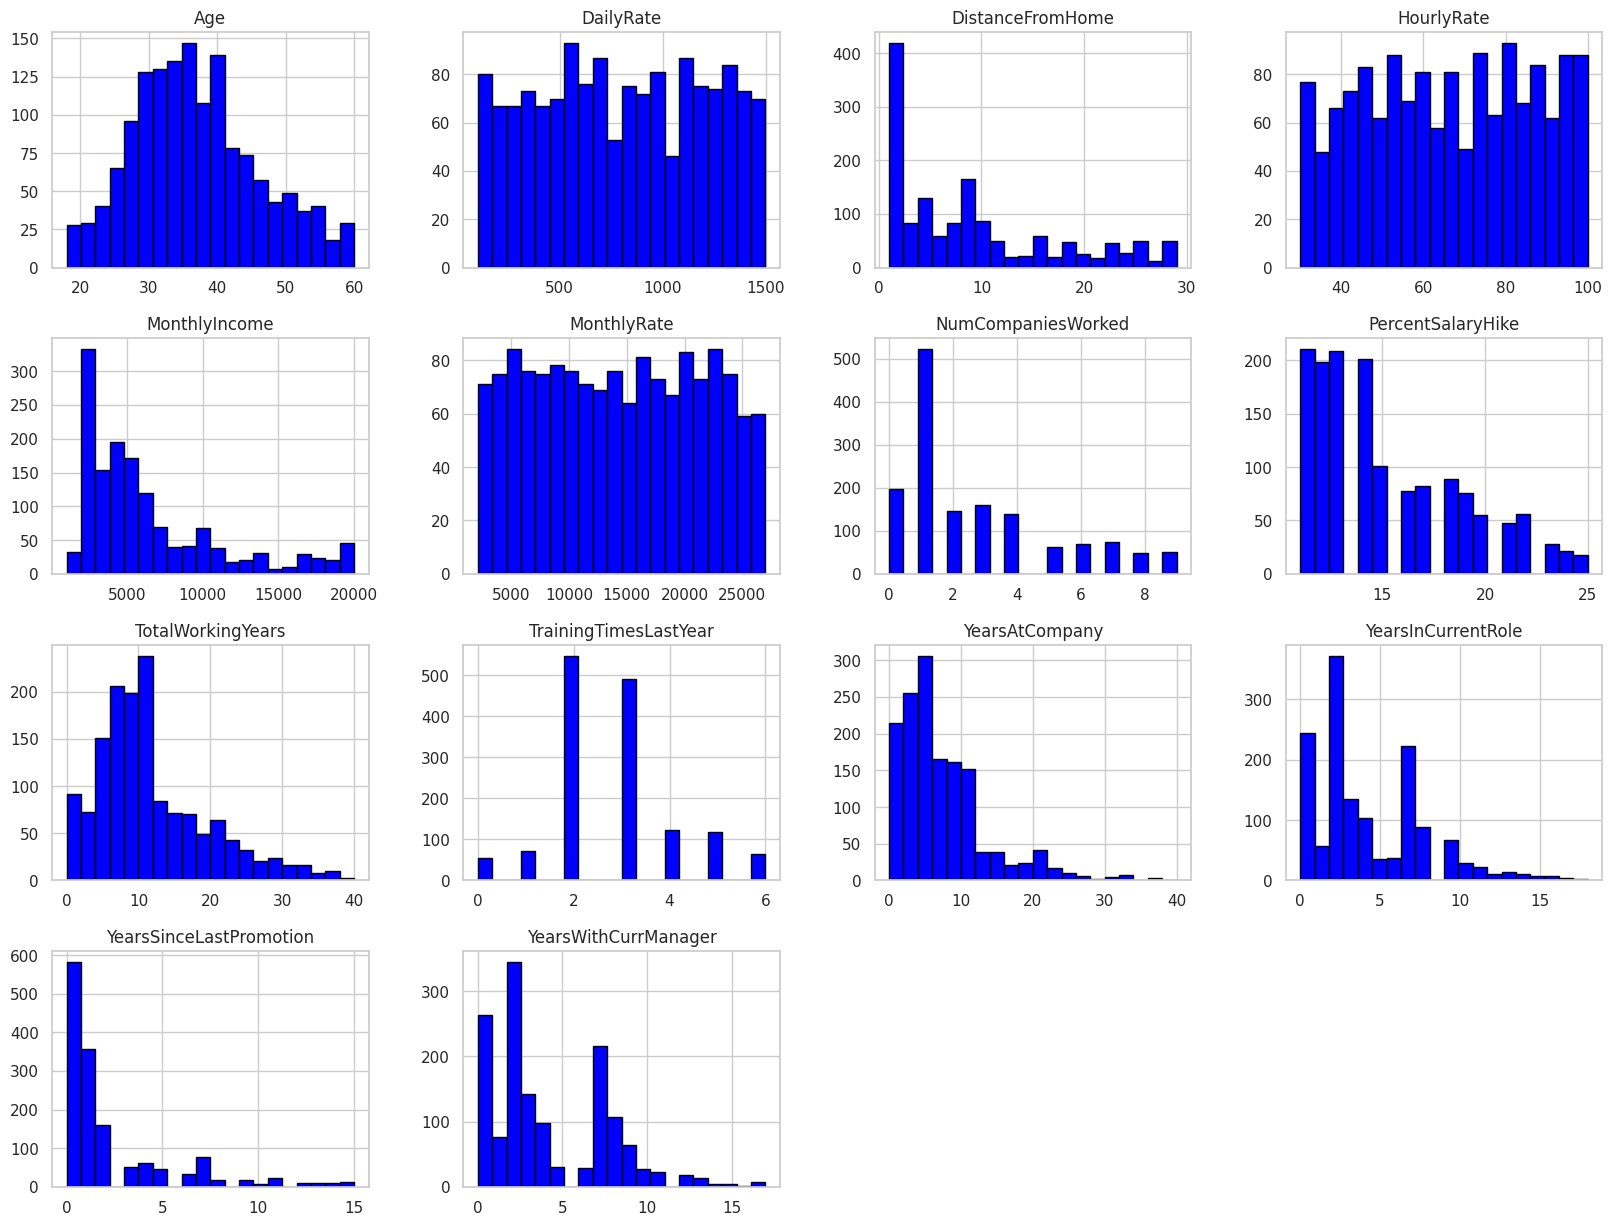

In [12]:
# Graficando variables numéricas

sns.set_theme(style="whitegrid")
data[variables_numericas].hist(figsize=(20, 15), bins=20, layout=(4,4), color = "blue", edgecolor = "black")
plt.title("Distribución Univariada de Variables Numéricas")
plt.tight_layout
plt.show()

**Observaciones para variables numéricas**


**1. Variables de "Alerta de Fuga" (Sesgo Positivo Extremo)**

Estas variables presentan la mayor Asimetría y Curtosis, lo que indica una concentración masiva en valores bajos y una "cola" de empleados en situaciones excepcionales.

**YearsSinceLastPromotion (Asim: 1.98 | Curt: 3.61):** Es la variable más desequilibrada. El histograma muestra un pico masivo en 0-1 años.

Interpretación: La mayoría se mueve rápido, pero existe un grupo estancado (outliers de hasta 15 años) que son candidatos naturales al Attrition.

**YearsAtCompany (Asim: 1.76 | Curt: 3.93):** Refleja una empresa con "sangre joven". La mayoría tiene menos de 5 años. La alta curtosis confirma que los empleados de más de 20 años son casos muy aislados.

**MonthlyIncome (Asim: 1.36 | Curt: 1.00):** La pirámide salarial es clara. El histograma muestra que el "grueso" de la empresa obtiene menos de $5,000, mientras que el resto de la distribución se estira hasta los $20,000.

---------------------------------------

**2. Variables de "Estabilidad y Contexto" (Distribución Normal / Moderada)**

Estas variables tienen una Asimetría cercana a 0.5 y Curtosis negativa, lo que indica datos bien distribuidos y confiables para la Regresión Logística.

**Age (Asim: 0.41 | Curt: -0.40):** Su histograma es el más equilibrado. Con una media de 36.9 años, IBM posee una fuerza laboral madura, pero jóven. Es una variable "ancla" que no presenta ruidos extraños.

**TotalWorkingYears (Asim: 1.11):** Aunque tiene sesgo, muestra una transición suave en el histograma. Refleja que la empresa contrata gente con experiencia previa consolidada (pico en 10 años).

**PercentSalaryHike (Asim: 0.82):** Muestra que los aumentos salariales son estandarizados. Los picos en 11-14% representan la política normal de la empresa; los valores superiores al 20% podrían ser excepciones por alto desempeño.

--------------------------------------

**3. Variables de "Ruido Estadístico" (Distribución Uniforme)**

Variables con Asimetría cercana a 0 y Curtosis muy negativa (-1.20).

Visualmente se ven como "bloques" planos. **DailyRate, HourlyRate y MonthlyRate:** No muestran ninguna tendencia. El empleado promedio puede estar en cualquier punto del rango sin una lógica clara.

**Nota:** Es probable que estas variables tengan una importancia baja en el modelo final, ya que no ayudan a diferenciar perfiles de empleados.



******

**Explorando variables ordinales**

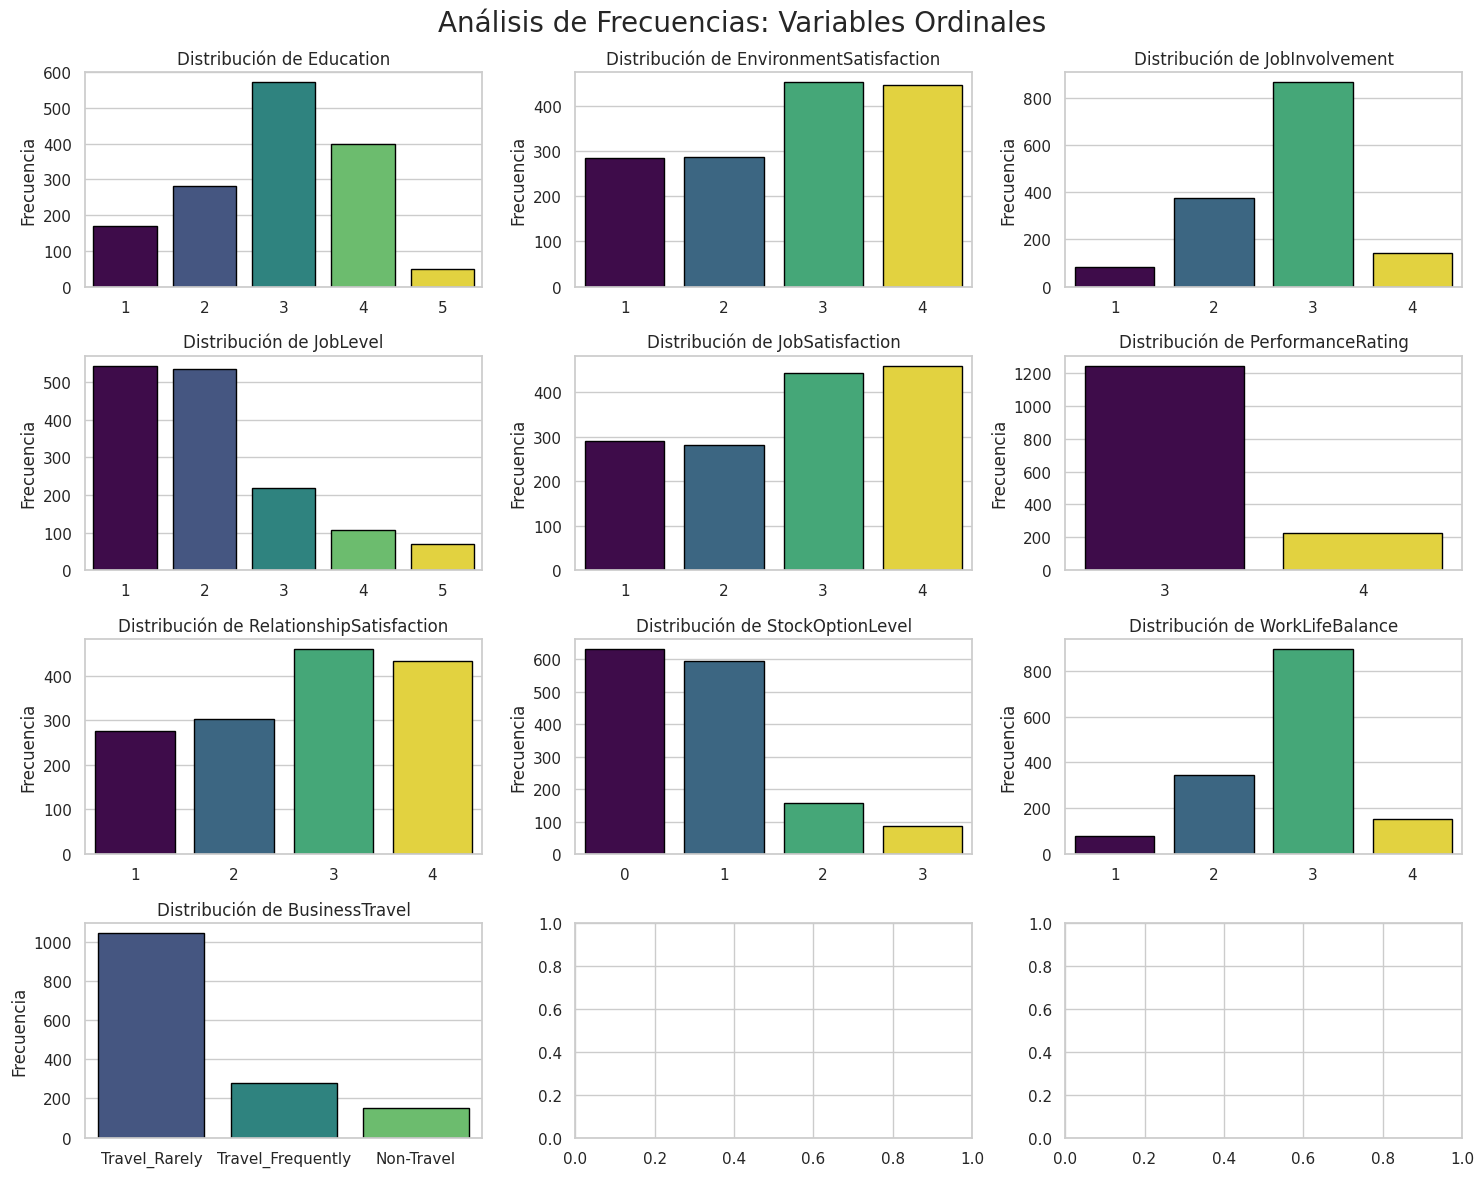

In [13]:
# Configuramos el lienzo para las 9 variables ordinales
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flat

for i, col in enumerate(variables_ordinales):
    # Asignamos 'x' a 'hue' y quitamos la leyenda para cumplir con la nueva norma de Seaborn
    sns.countplot(x=col, data=data, ax=axes[i], hue=col, palette='viridis', edgecolor='black', legend=False)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Análisis de Frecuencias: Variables Ordinales', fontsize=20)
plt.tight_layout()
plt.show()

**Observaciones para vaiables ordinales**

**1. Perfil de Alta Capacitación pero Bajo Techo:**

Se tiene personal con alta educación (Education 3-4 correspondientes a estudioes de nivel licenciatura y maestría respectivamente) en niveles de puesto bajos (JobLevel 1-2). Esto crea una fuerza laboral sobrecalificada con probable tendencia a sentirse frustrada si no ve crecimiento.

------------------------------------

**2. Sistema de Evaluación Generoso:**

El PerformanceRating está sesgado solo a lo excelente, ya que de 4 niveles (1-4) solo se aprecian 3 y 4. Esto sugiere que las evaluaciones de desempeño podrían no estar reflejando la realidad o que no hay consecuencias para el desempeño bajo, lo que desmotiva a los "top performers".

-----------------------------------

**3. Falta de Incentivos de Retención a Largo Plazo:**

Con un StockOptionLevel mayoritariamente en 0, no hay incentivos financieros que "aten" al empleado a la empresa durante ciclos económicos difíciles.

------------------------------------

**4. Focos de Insatisfacción Crítica:**

En todas las variables de satisfacción (Environment, Job, Relationship), existe un "núcleo duro" de nivel 1 (aproximadamente el 18-20% de la plantilla). Este es el segmento donde probablemente se encontrará la mayor tasa de Attrition.

-------------------------------------------------

**Explorando variables nominales**

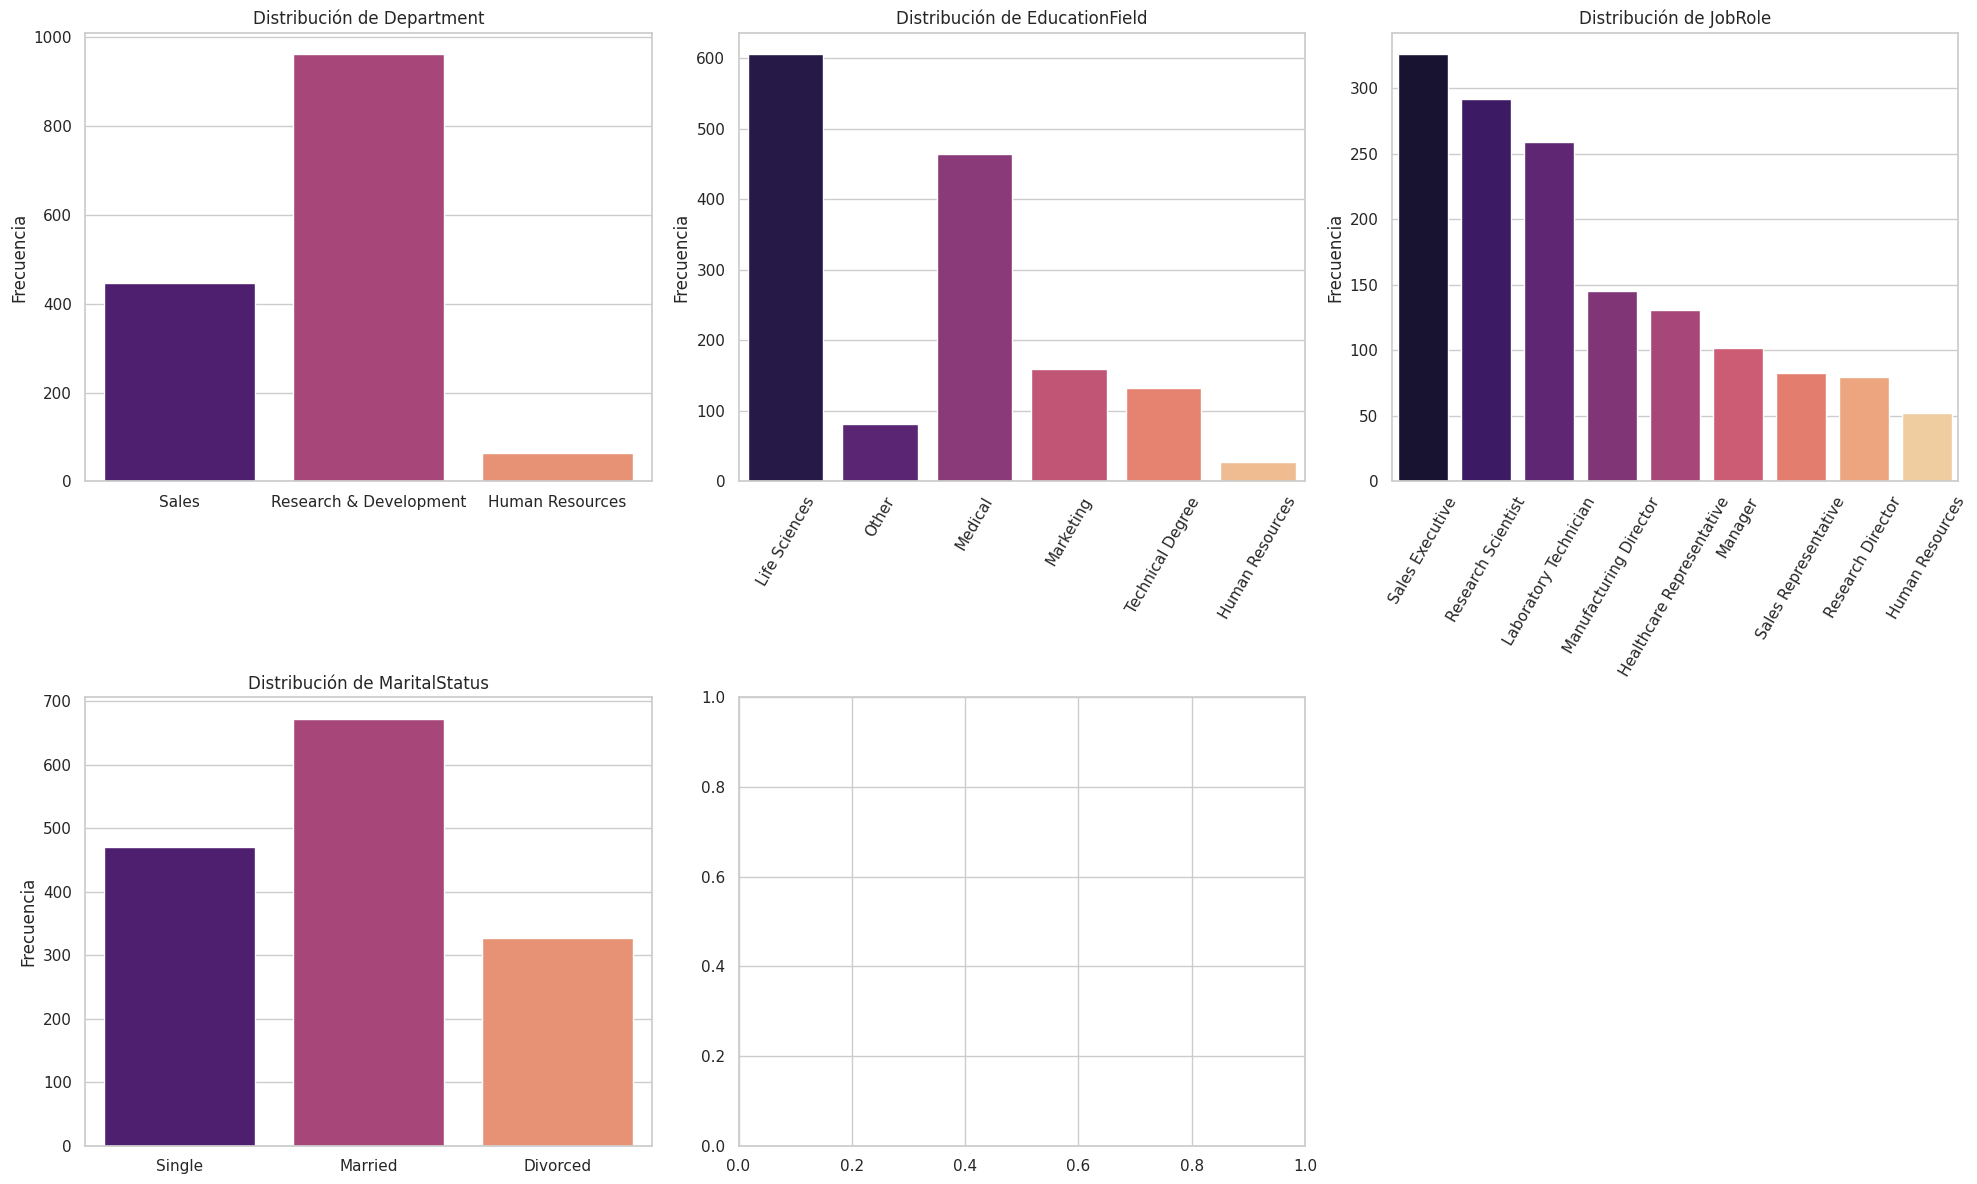

In [14]:
# Visualizando variables nominales
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flat

for i, col in enumerate(variables_nominales):
    sns.countplot(x=col, data=data, ax=axes[i], hue=col, palette='magma', legend=False)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

    # Ajuste para etiquetas largas
    if col in ['JobRole', 'EducationField']:
        axes[i].tick_params(axis='x', rotation=60)

# Eliminamos el sexto espacio vacío
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Observaciones de variables nominales**

**1. Concentración en el Núcleo Operativo (R&D):**

La empresa está fuertemente centralizada en Investigación y Desarrollo. Esto implica que cualquier política de retención o cambio organizacional tendrá un impacto desproporcionado en este departamento. Los perfiles técnicos y científicos parecen ser el núcleo de la organización en este dataset.

--------------------------------

**2. Fragmentación de Roles (Especialización):**

Existe una gran variedad de puestos (JobRole), pero con una dominancia clara de Sales Executives y Research Scientists. Esta especialización sugiere que el modelo de clasificación deberá ser capaz de distinguir si las razones de renuncia son las mismas para un vendedor (enfocado en metas) que para un científico (enfocado en proyectos).

-------------------------------

**3. Baja movilidad ejecutiva:**

La escasez de puestos de nivel Manager o Director en comparación con la base operativa refuerza la teoría del "Techo de Cristal". Al haber pocos puestos de liderazgo, los empleados con alta preparación académica podrían percibir una falta de futuro profesional dentro de la empresa. En escencia se crea un cuello de botella respecto al crecimiento profesional dentro de la organización.

------------------------------

**4. Estabilidad Familiar vs. Riesgo de Movilidad:**

Aunque el estado civil predominante es Casado, el volumen de empleados Solteros es significativo. En el contexto de análisis de rotación, los solteros suelen tener una elasticidad mayor para cambiar de empleo o ciudad, lo que los convierte en un grupo de interés primordial para el análisis bivariado contra Attrition

---------------------------------------------------------


**Explorando variables binarias**

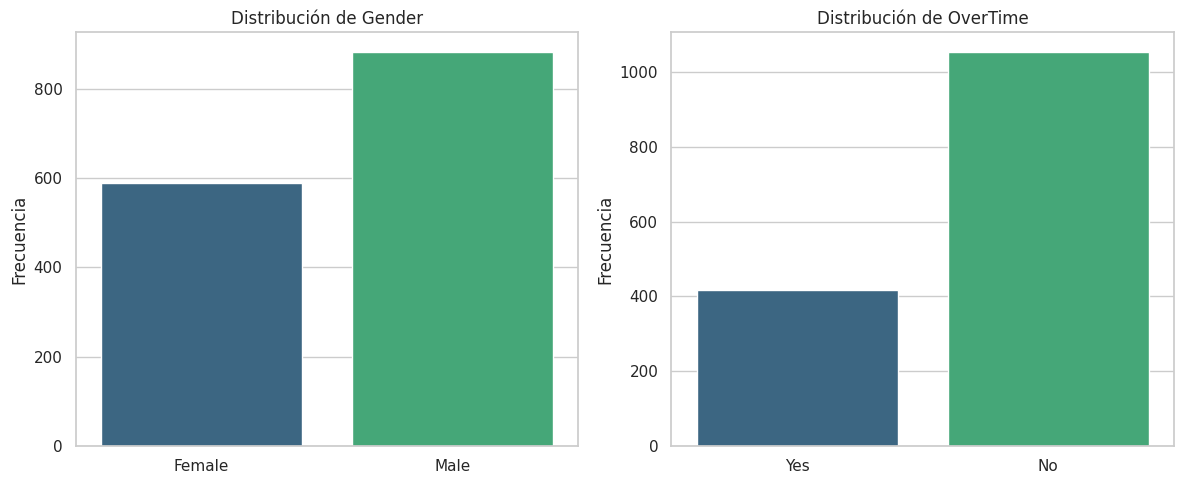

In [15]:
# Visualizando variables binarias
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for i, col in enumerate(variables_binarias):
    sns.countplot(x=col, data=data, ax=axes[i], hue=col, palette='viridis', legend=False)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Observaciones para variables binarias**


**1. Gender (Género)**

Hay una mayor representación de hombres en la muestra (casi 900) frente a las mujeres (cerca de 600).

Existe una brecha de género en la plantilla. Para el modelo de IA, esto significa que los patrones de comportamiento masculinos tendrán un poco más de peso.

**Pregunta de análisis:** ¿Será que el género influye en la decisión de irse? Se verificará en el análisis bivariado, pero es un dato demográfico base muy importante.

**2. OverTime (Horas Extra):**

La gran mayoría de los empleados no trabaja horas extra. Sin embargo, hay un bloque de aproximadamente 400 personas que sí lo hace de manera recurrente.

**Insight de Negocio:** En analítica de talento, el OverTime suele ser el predictor número uno de renuncia por agotamiento (burnout).

**Hipótesis:** Es muy probable que al cruzar este hallazgo contra Attrition, se note que el porcentaje de gente que se va es mucho más alto en el grupo de "Yes" que en el de "No".

---------------------------------------------------

**Análisis bivariado**

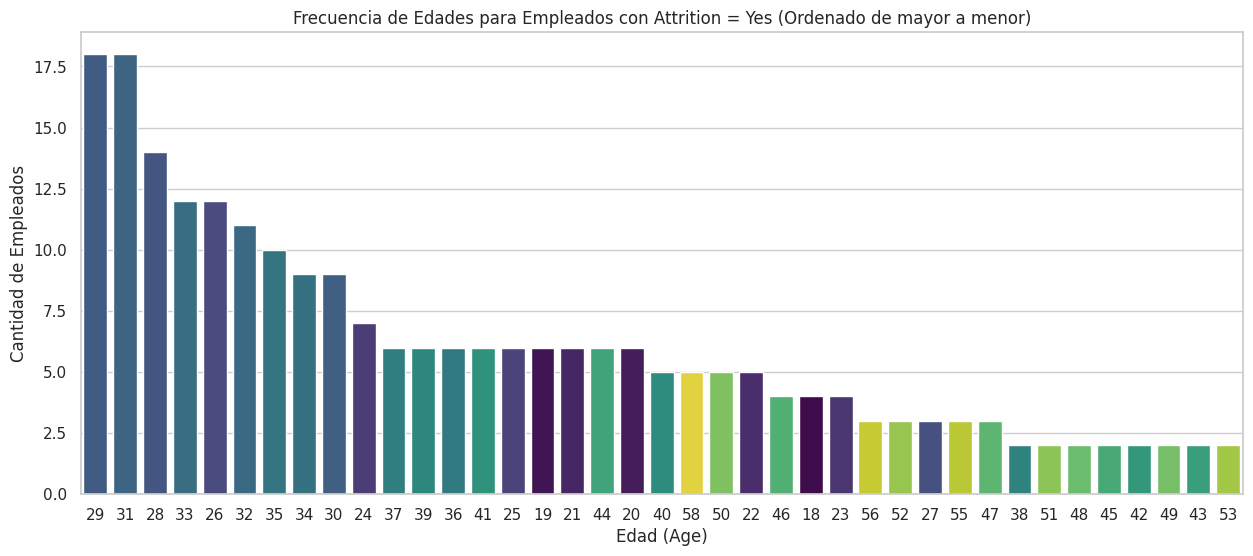

In [16]:
# Grafico de Attrition contra Edad

# Se filtran los datos para empleados que ya no están (Attrition = 'Yes')
attrition_yes = data[data['Attrition'] == 1]

# Se calcula las frecuencias de la variable 'Age' y ordenamos de mayor a menor
age_counts = attrition_yes['Age'].value_counts().sort_values(ascending=False)

# Se crea el gráfico de barras corregido
plt.figure(figsize=(15, 6))
sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    order=age_counts.index,
    hue=age_counts.index,
    palette='viridis',
    legend=False           # Quitamos la leyenda porque es redundante aquí
)

plt.title('Frecuencia de Edades para Empleados con Attrition = Yes (Ordenado de mayor a menor)')
plt.xlabel('Edad (Age)')
plt.ylabel('Cantidad de Empleados')
plt.show()

**Observaciones Attrition vs Age**

Noto que la gente que más se va es relativamente joven , entre 26 y 35 años, siendo los que más se van al rededor de los 30 con picos pronucniados en 29 y 31.

**El Salto en la Curva Salarial:** En este rango de edad, las personas ya tienen de 3 a 8 años de experiencia. Es el momento donde un cambio de empresa suele representar un aumento salarial de entre el 15% y 20%, comparado con el aumento anual estándar (3-5%) si se quedan en el mismo lugar.

**Búsqueda de Crecimiento (Up-skilling):** Los posgrados son un factor. Muchos profesionales a los 28-32 años deciden hacer un MBA o una maestría técnica para dar el salto a puestos gerenciales. Si la empresa actual no ofrece ese camino de ascenso rápido, buscan fuera.

**Etapas de Vida y Flexibilidad:** Es la etapa donde ocurren hitos personales como el matrimonio, la compra de una primera vivienda o tener hijos. Esto cambia las prioridades: un empleado que a los 23 años no le importaba trabajar horas extra, a los 31 busca balance vida-trabajo y flexibilidad (home office), algo que se ve reflejado en "Horas Extra" en el punto 6a como un foco rojo.

**El "Job Hopping":** En el sector tecnológico (donde opera IBM), existe menos estigma por cambiar de trabajo cada 2 o 3 años. De hecho, se percibe como una forma de ganar experiencia en diferentes pilas tecnológicas o metodologías.

**Referencias**

Gallup - El costo de la rotación en Millennials: https://www.gallup.com/workplace/238073/millennials-work-live.aspx / Este estudio detalla por qué este grupo demográfico es el más propenso a cambiar de empleo y el impacto económico para las empresas.

LinkedIn Learning - Reporte de aprendizaje en el trabajo 2023: https://learning.linkedin.com/resources/workplace-learning-report / Explica la relación entre la retención de empleados jóvenes y las oportunidades de crecimiento profesional.

Pew Research Center - Por qué la gente renunció a sus empleos: https://www.pewresearch.org/short-reads/2022/03/09/majority-of-workers-who-quit-a-job-in-2021-cite-low-pay-no-opportunities-for-advancement-feeling-disrespected/?gad_source=1&gad_campaignid=22378837192&gbraid=0AAAAA-ddO9FdMBHw8Vr4Kg9MT6UOi154j&gclid=Cj0KCQiAkPzLBhD4ARIsAGfah8hqDUs6W5wtC0gamRdgd1IE9UIeq_E4rCzwTOO9YRQFVzuuvWY9eXYaAiCIEALw_wcB / Presenta estadísticas claras sobre los motivos de renuncia divididos por grupos de edad.

Harvard Business Review - Por qué la gente renuncia: https://hbr.org/2016/09/why-people-quit-their-jobs / Un análisis profundo sobre los "disparadores" de renuncia, incluyendo hitos de edad como cumplir 30 años.

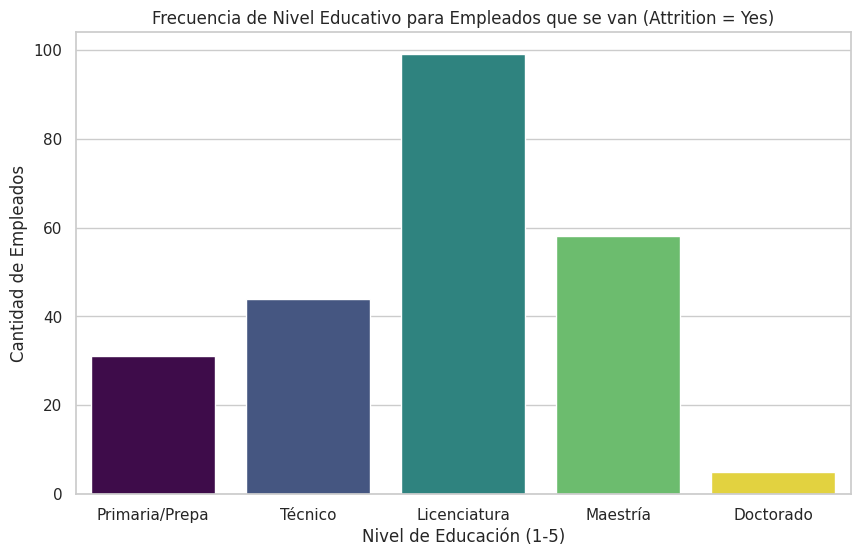

In [17]:
# Nivel educativo contra Attrition

# Calculamos frecuencias del nivel educativo
edu_counts = attrition_yes['Education'].value_counts().sort_index()

#  Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    hue=edu_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Frecuencia de Nivel Educativo para Empleados que se van (Attrition = Yes)')
plt.xlabel('Nivel de Educación (1-5)')
plt.ylabel('Cantidad de Empleados')
plt.xticks(ticks=[0,1,2,3,4], labels=['Primaria/Prepa', 'Técnico', 'Licenciatura', 'Maestría', 'Doctorado'])
plt.show()

**Observaciones Grado Educativo vs. Attrition**

**Dominancia de la Licenciatura (Nivel 3):** Con casi 100 bajas, este es el grupo más crítico. Coincide la hipótesis de los 29-31 años: profesionales que terminaron su carrera hace unos 6-8 años y ahora están en el mercado abierto buscando ese salto del 15-20% salarial.

**El Peso de la Maestría (Nivel 4):** Hay cerca de 60 bajas en este nivel. Esto respalda el punto sobre el Up-skilling. Los empleados con posgrado tienen un valor de mercado más alto y son más propensos a recibir ofertas agresivas de la competencia.

**Baja incidencia en Doctorados (Nivel 5):** Aquí hay que ser cautelosos. Como vimos en el análisis univariado, hay muy pocos doctores en la empresa. Aunque la barra es pequeña, no significa que no se vayan, sino que la muestra es menor.

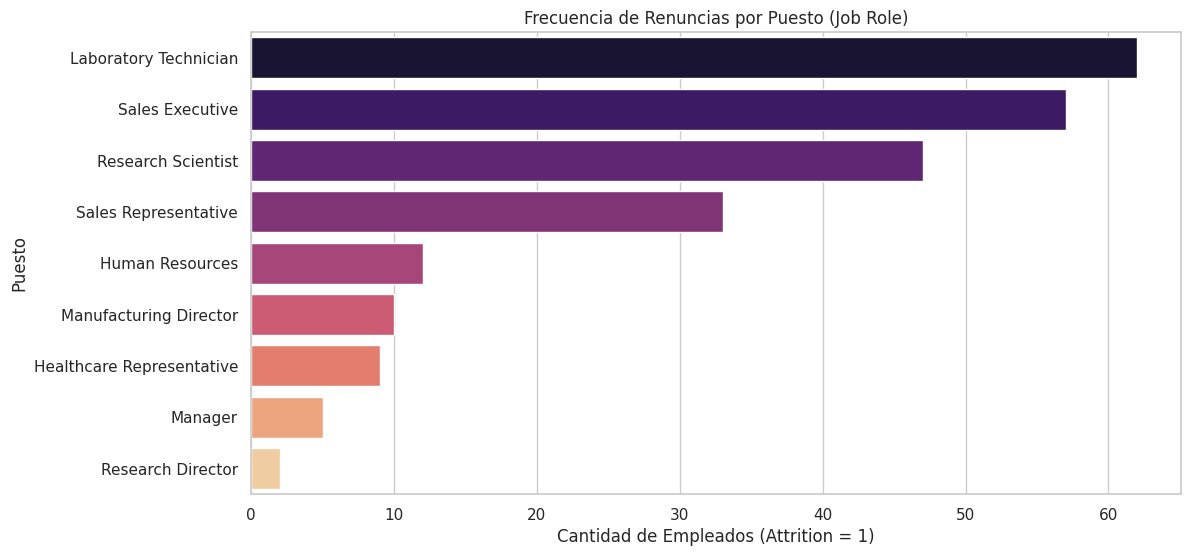

In [18]:
# Puesto de trabajo contra Attrition

# Calculamos frecuencias por Puesto para los que se van
job_counts = attrition_yes['JobRole'].value_counts()

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x=job_counts.values,
    y=job_counts.index,
    hue=job_counts.index,
    palette='magma',
    legend=False
)

plt.title('Frecuencia de Renuncias por Puesto (Job Role)')
plt.xlabel('Cantidad de Empleados (Attrition = 1)')
plt.ylabel('Puesto')
plt.show()

**Observaciones para JobRole contra Attrition**

**1. Los tres puestos con mayor cantidad de bajas:** Coinciden con el "núcleo" visto en el análisis univariado, pero con un matiz importante:

**Laboratory Technician (poco más de 60 bajas):** Es el puesto número uno. Generalmente, estos roles tienen una carga de trabajo muy repetitiva y, en muchas empresas, son vistos como puestos "de entrada" con poca trayectoria de crecimiento, lo que empuja a los técnicos a buscar mejores salarios o roles de mayor jerarquía pronto.

**Sales Executive (casi 60 bajas):** Las ventas son estresantes por naturaleza. Aquí la rotación suele estar ligada al cumplimiento de cuotas y a la búsqueda de mejores esquemas de comisiones en la competencia.

**Research Scientist (casi 50 bajas):** Esto es crítico. Perder científicos es perder el "know-how" técnico de la empresa. Probablemente aquí es donde se concentran esos licenciados y maestros de al rededor de 30 años que se detectaron anteriormente.

**2. El caso de los Sales Representatives:**

Aunque tienen menos bajas en número absoluto (poco más de 30) que los ejecutivos, en el análisis univariado era evidente que había pocos representantes en total. Esto sugiere que la tasa proporcional de renuncia es altísima. Es un puesto que parece estar "quemando" a la gente muy rápido, lo que no es inusual en el giro de ventas en general.

**3. La Estabilidad en la Cima:**

Como ya se había anticipado, los puestos de Manager y Research Director casi no tienen bajas. Esto confirma la conclusión anterior: hay poco movimiento en la parte alta de la pirámide, lo que genera ese "cuello de botella" para los que están abajo.

**En resumen:** En este punto si se tuviera que describir al empleado con mayor probabilidad de irse, sería:

**Un Técnico de Laboratorio o Ejecutivo de Ventas, de aproximadamente 30 años (picos en 29 y 31), con nivel de Licenciatura.**

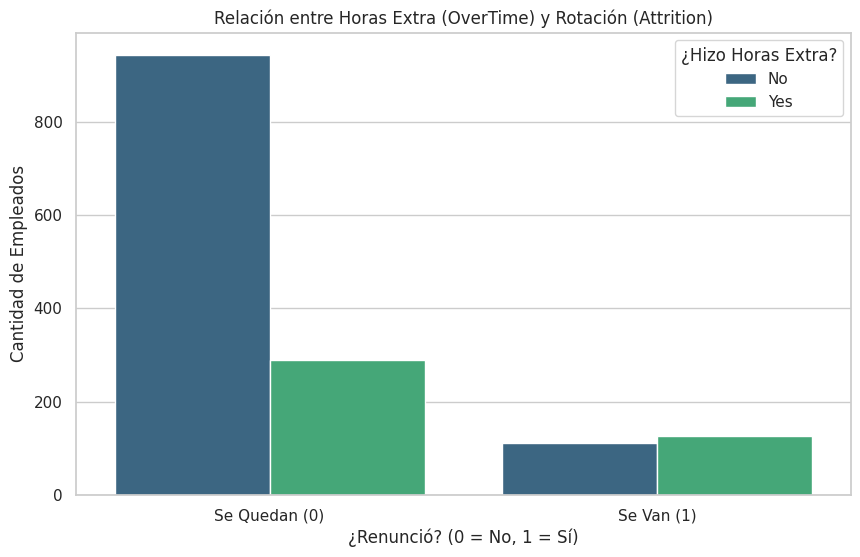

In [19]:
# Over Time contra Attrition

plt.figure(figsize=(10, 6))

# Graficamos Attrition en el eje X y usamos OverTime para dividir las barras
sns.countplot(x='Attrition', hue='OverTime', data=data, palette='viridis')

# Personalizamos los nombres en los ejes para que sea más profesional
plt.title('Relación entre Horas Extra (OverTime) y Rotación (Attrition)')
plt.xlabel('¿Renunció? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Empleados')
plt.xticks(ticks=[0, 1], labels=['Se Quedan (0)', 'Se Van (1)'])
plt.legend(title='¿Hizo Horas Extra?')

plt.show()

**Observaciones Overtime contra Attrition**

Lo más impactante no es el número total, sino la proporción dentro de cada grupo:

**En el grupo que se queda (Attrition = 0):** La gran mayoría (la barra azul alta) no trabaja horas extra. Solo una pequeña fracción de los empleados leales tiene carga extra de trabajo.

**En el grupo que se va (Attrition = 1):** Aquí está el punto clave, ya que las barras están casi igualadas. Se nota que la cantidad de personas que renuncian y trabajan horas extra es un poco mayor a la de los que renuncian sin tenerlas.

**Esto es importante porque:** Si las horas extra no influyeran, la relación en el grupo de "Yes" o 1, debería ser igual de desigual que en el de "No" o 0. Sin embargo, se puede ver que trabajar horas extra dispara la probabilidad de estar en el grupo de renuncia.

**A manera de sinopsis:**

El gráfico demuestra que las horas extra son un catalizador de la rotación. Mientras que en la población general de la empresa las horas extra son poco comunes, en el grupo de empleados que renuncian, estas representan prácticamente la mitad de los casos. Esto sugiere que para los perfiles de licenciatura y maestría (que ya identificamos como los más móviles), el agotamiento por jornadas extendidas es probablemente el factor final que los motiva a buscar nuevas oportunidades laborales con mejor balance de vida.

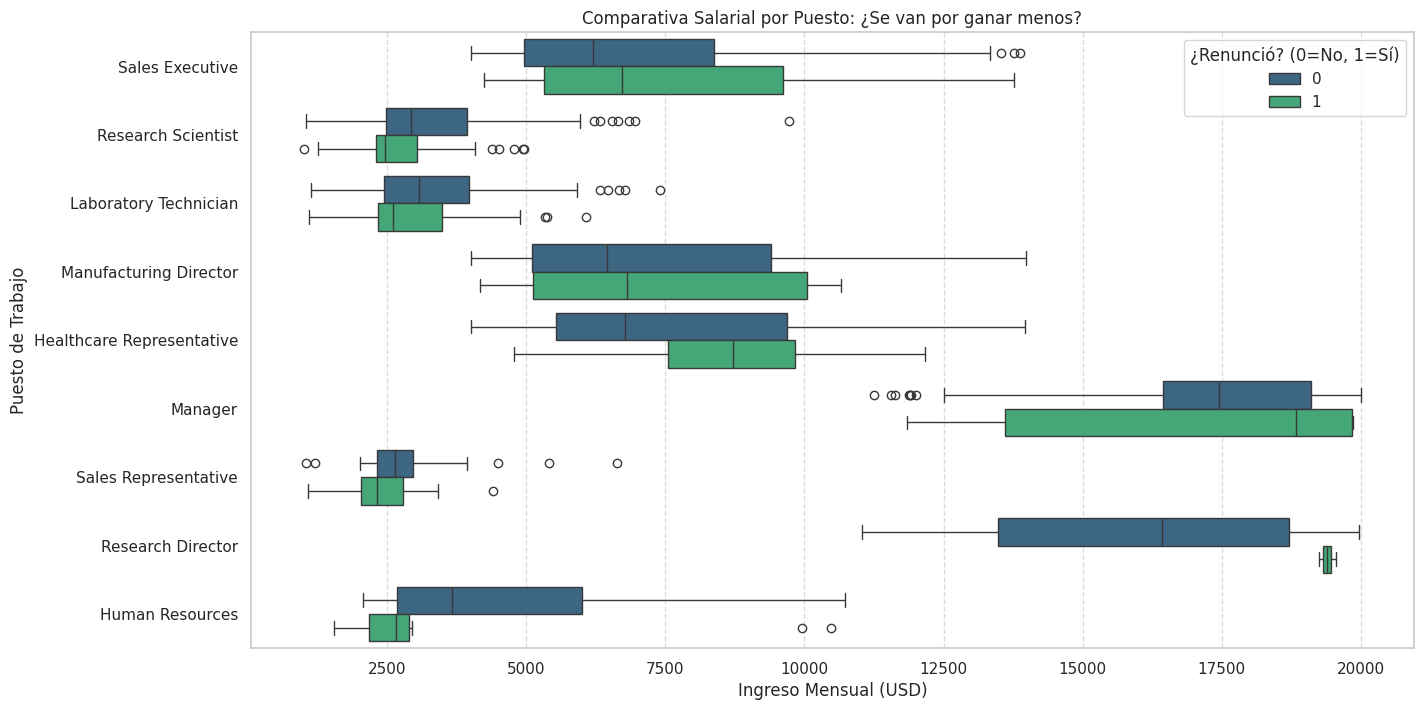

In [20]:
# Análisis de ingresos por puesto

plt.figure(figsize=(15, 8))

# Creamos un Boxplot comparando ingresos por puesto, divididos por Attrition
sns.boxplot(x='MonthlyIncome', y='JobRole', hue='Attrition', data=data, palette='viridis')

plt.title('Comparativa Salarial por Puesto: ¿Se van por ganar menos?')
plt.xlabel('Ingreso Mensual (USD)')
plt.ylabel('Puesto de Trabajo')
plt.legend(title='¿Renunció? (0=No, 1=Sí)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Observaciones para Análisis de Ingresos por Puesto**

**1. Los que se van por dinero (Sales Representatives)**

Es el caso más claro en la gráfica. Si se observa con atención, el puesto de Sales Representative, la "caja" verde (los que se van) está claramente más a la izquierda que la azul.

**Interpretación:** En este rol, quienes renuncian ganan significativamente menos que sus compañeros que deciden quedarse. Aquí el salario es un factor predictor directo de la fuga.

**2. Los que se van por otras razones (Técnicos y Científicos):**

Para **Laboratory Technician y Research Scientist** Las cajas verde y azul están casi encimadas.

**Interpretación:** No hay una diferencia salarial real entre los que se quedan y los que se van. Esto valida la conclusión anterior: como el sueldo es casi el mismo para todos en la base, el detonante de la renuncia no es el ingreso mensual, sino el burnout por horas extra o la falta de crecimiento mencionada anteriormente.

**3. El techo salarial**

Casi todos los puestos que presentan alta rotación (los de la parte baja del gráfico) tienen sus cajas concentradas por debajo de los $5,000 USD.

**Interpretación:** Existe una brecha enorme comparado con los Managers o Directors (que ganan más de $15,000). Esta disparidad salarial tan marcada suele desmotivar al talento de nivel medio (los licenciados o maestros de al rededor de 30 años), haciéndoles sentir que el camino para subir el sueldo dentro de la empresa es demasiado largo, ya que este por lo regular proviene de promociones de púesto que casi no haym provocando el cuello de botella antes mencionado también.

**4. Puntos fuera de la caja (Outliers)**

Esos pequeños círculos que se ven a la derecha de algunas barras representan a personas que ganan mucho más que el promedio de su puesto. Se puede notar que casi todos son círculos azules (gente que se queda).

**Interpretación:** El dinero funciona como un "ancla". Los que logran obtener un sueldo por encima del promedio de su puesto tienen una probabilidad casi nula de renunciar.

**En conclusión:**

El salario solo es el culpable directo en el área de Ventas. Para el resto de los departamentos críticos, el problema es estructural: sueldos bajos en general y estancados, lo que combinado con las horas extra descubiertas en el gráfico anterior, crea la situación para que se detone la rotación.

-----------------------------------------------------

**Fase: Ingeniería de Características (Feature Engineering)**

Para la presente etapa del proceso será necesario mapear a numéros las variables que no son binarias. Esto se hace debido a que el modelo de ML que se implementará más adelante no es capáz de entender palabras, sino números.

Además, este paso es fundamental para poder visualizar una matríz de correlación y ver que tanto influye una variable sobre otra. De nuevo, este proceso solo es viable teniendo las variables en "números".

In [21]:
# Mapeo para variables binarias
mapeo_overtime = {'No': 0, 'Yes': 1}
mapeo_gender = {'Female': 0, 'Male': 1}

#aplicando mapeo
data['OverTime'] = data['OverTime'].map(mapeo_overtime)
data['Gender'] = data['Gender'].map(mapeo_gender)

# Verificando tranformación
data[['OverTime', 'Gender']].head()

,OverTime,Gender
0,1,0
1,0,1
2,1,1
3,1,0
4,0,1


In [22]:
# Mapeo para variables ordinales
data[variables_ordinales].head()

,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance,BusinessTravel
0,2,2,3,2,4,3,1,0,1,Travel_Rarely
1,1,3,2,2,2,4,4,1,3,Travel_Frequently
2,2,4,2,1,3,3,2,0,3,Travel_Rarely
3,4,4,3,1,3,3,3,0,3,Travel_Frequently
4,1,1,3,1,2,3,4,1,3,Travel_Rarely


In [23]:
# Como se puede apreciar todas las variables ordinales ya se encuentran en un formato correcto, a excepción de BusinessTravel.
# De acuerdo con el resumen_naturaleza:
print(f'Los niveles de BusinessTravel son: {data['BusinessTravel'].value_counts()}')


Los niveles de BusinessTravel son: BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


In [24]:
# Mapeo para BusinessTravel
mapeo_businesstravel = {
  'Non-Travel': 0,
  'Travel_Rarely': 1,
  'Travel_Frequently': 2,
}

# aplicando mapeo
data['BusinessTravel'] = data['BusinessTravel'].map(mapeo_businesstravel)

# Verificando mapeo
print(f'Ahora los niveles de BusinessTravel son: {data['BusinessTravel'].value_counts()}')


Ahora los niveles de BusinessTravel son: BusinessTravel
1    1043
2     277
0     150
Name: count, dtype: int64


In [25]:
# Confirmando formato correcto de variables ordinales
data[variables_ordinales].head()

,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance,BusinessTravel
0,2,2,3,2,4,3,1,0,1,1
1,1,3,2,2,2,4,4,1,3,2
2,2,4,2,1,3,3,2,0,3,1
3,4,4,3,1,3,3,3,0,3,2
4,1,1,3,1,2,3,4,1,3,1


In [26]:
# Mapeo para variables nominales
data[variables_nominales].head()

,Department,EducationField,JobRole,MaritalStatus
0,Sales,Life Sciences,Sales Executive,Single
1,Research & Development,Life Sciences,Research Scientist,Married
2,Research & Development,Other,Laboratory Technician,Single
3,Research & Development,Life Sciences,Research Scientist,Married
4,Research & Development,Medical,Laboratory Technician,Married


In [27]:
# Aplicamos One-Hot Encoding a todo el bloque nominal
data = pd.get_dummies(data, columns=variables_nominales, drop_first=True)

# Verificamos cómo quedaron las nuevas columnas (mostramos las últimas 20)
print(f"Total de columnas ahora: {data.shape[1]}")
data.iloc[:, -20:].head()

Total de columnas ahora: 44


,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,4,0,5,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,7,1,7,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,0,0,0,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,7,3,0,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,2,2,2,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False


In [28]:
# Por tener coherencia en la sintaxis se procederá a cambiar los True por 1 y los False por 0.
# Aunque no es relevante este cambio, ya que para Python y la mayoría de las librerías de Machine Learning (como Scikit-Learn), True es equivalente a 1 y False es equivalente a 0.
# Reirtero, es para convervar la coherencia de la sintaxis.

data = data.replace({True: 1, False: 0})
data.iloc[:, -20:].head()

/tmp/ipykernel_8590/37245519.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({True: 1, False: 0})


,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,4,0,5,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
1,7,1,7,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
3,7,3,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,2,2,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0


In [29]:
# Ahora que el dataset original ya es una matríz de números, es posible verificar la correlación de las variables contra Attrition.
# De esta manera se espera "ver" qué variables son viables descartar para evitar en medida de lo posible la multicolinealidad.

# para calcular la correlación de Pearson para todo el dataset
matriz_corr = data.corr()

# Extraemos solo la relación con Attrition y ordenamos
atencion_attrition = matriz_corr['Attrition'].sort_values(ascending=False)

print("Factores que IMPULSAN la renuncia (Correlación Positiva):")
print(atencion_attrition.head(10))

print("\nFactores que RETIENEN al personal (Correlación Negativa):")
print(atencion_attrition.tail(10))

Factores que IMPULSAN la renuncia (Correlación Positiva):
Attrition                          1.000000
OverTime                           0.246118
MaritalStatus_Single               0.175419
JobRole_Sales Representative       0.157234
BusinessTravel                     0.127006
JobRole_Laboratory Technician      0.098290
Department_Sales                   0.080855
DistanceFromHome                   0.077924
EducationField_Technical Degree    0.069355
EducationField_Marketing           0.055781
Name: Attrition, dtype: float64

Factores que RETIENEN al personal (Correlación Negativa):
JobSatisfaction        -0.103481
JobInvolvement         -0.130016
YearsAtCompany         -0.134392
StockOptionLevel       -0.137145
YearsWithCurrManager   -0.156199
Age                    -0.159205
MonthlyIncome          -0.159840
YearsInCurrentRole     -0.160545
JobLevel               -0.169105
TotalWorkingYears      -0.171063
Name: Attrition, dtype: float64


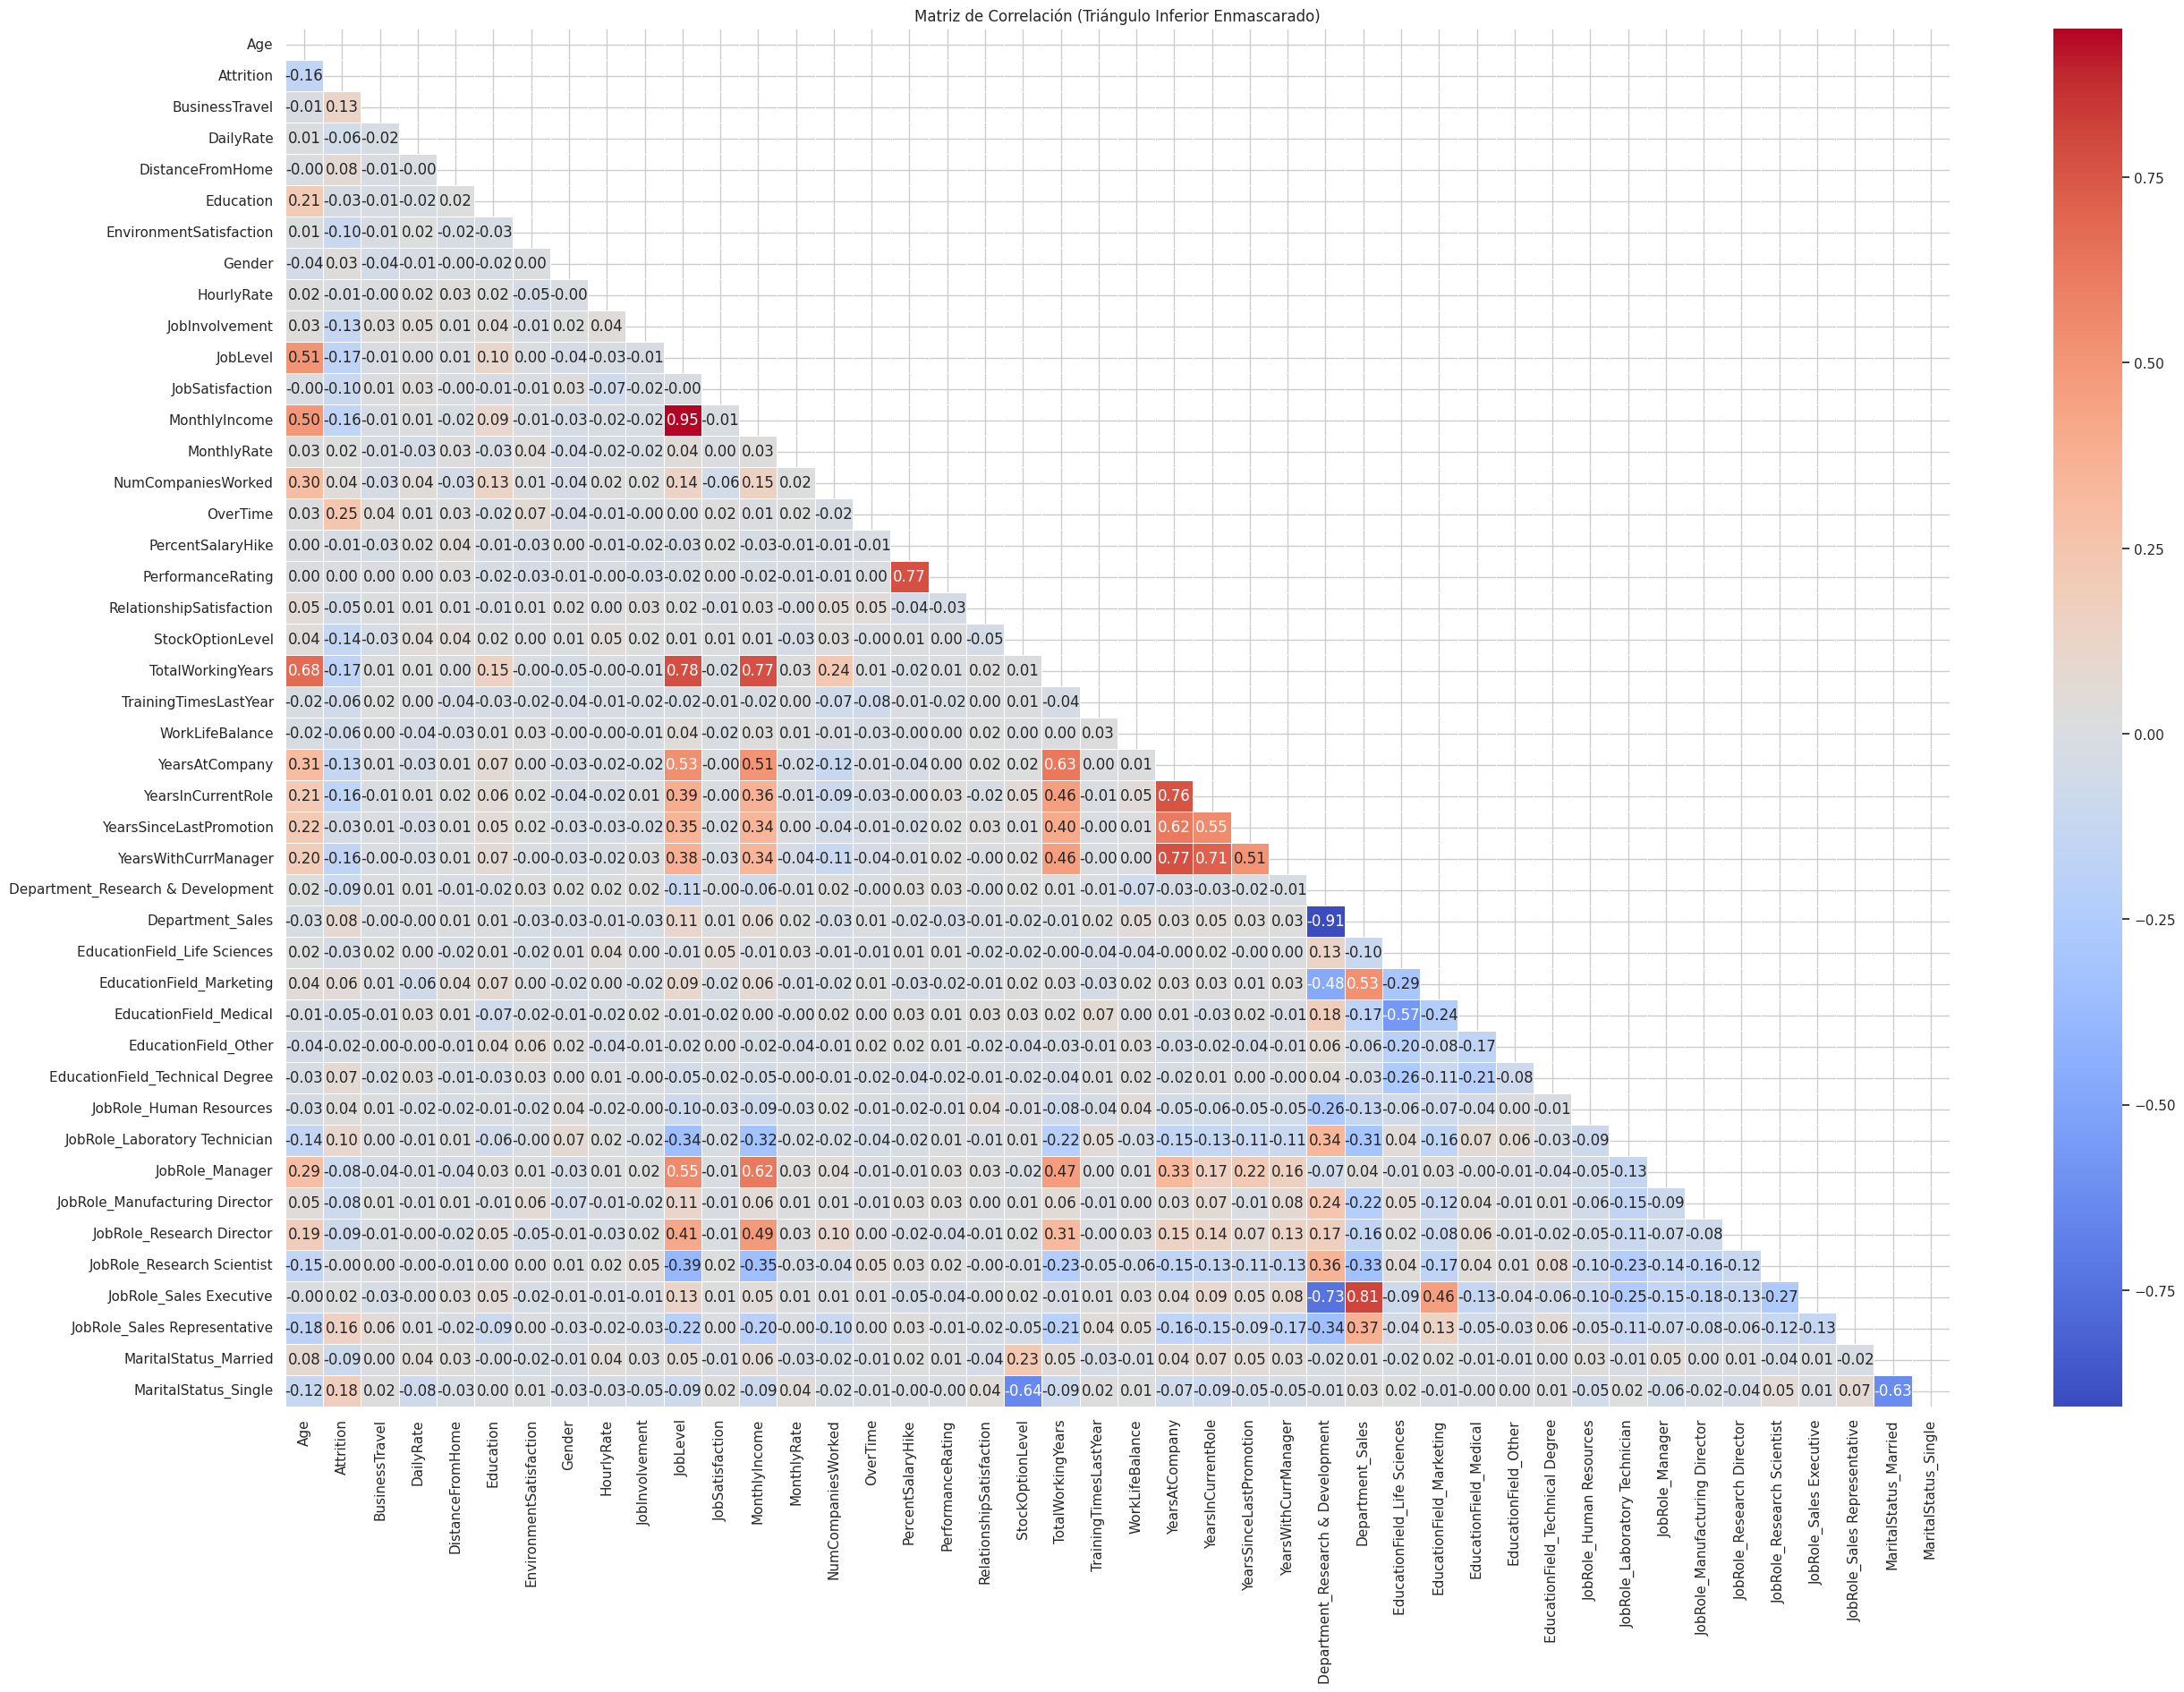

In [30]:
# Para visualizar la matríz de "Todos contra Todos"

# Generamos una máscara para el triángulo superior
# np.triu crea una matriz con unos en la parte superior, que luego usamos para ocultar
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Configuramos el gráfico
plt.figure(figsize=(30, 20))

# Dibujamos el Heatmap con la máscara
sns.heatmap(matriz_corr,
            mask=mask,          # Aquí aplicamos la máscara
            cmap='coolwarm',
            annot=True,
            fmt=".2f",
            linewidths=0.5)

plt.title('Matriz de Correlación (Triángulo Inferior Enmascarado)')
plt.show()

In [31]:
# Con base en la matríz anterior, se pueden detectar las columnas con multicolinealidad.
# Es nececario crear una instancia de dicha matríz para poder posteriormente eliminar las variables detectadas visualmente.
# Usamos la matriz_corr existente, pero con valores absolutos. Esto con la finalidad de detectar correlaciones positivas y negativas a la vez.
upper = matriz_corr.abs().where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

# Lista de columnas que tienen al menos una correlación > 0.80 con otra
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print("Variables que causan redundancia (Multicolinealidad):")
print(to_drop)

Variables que causan redundancia (Multicolinealidad):
['MonthlyIncome', 'Department_Sales', 'JobRole_Sales Executive']


**Observaciones para variables redundantes**

**1. Variable: MonthlyIncome**

**Hallazgo:** Presenta una correlación de 0.95 con la variable JobLevel.

**Justificación:** Existe una relación de dependencia casi lineal entre el rango jerárquico y el salario. Mantener ambas variables introduciría ruido en el modelo (inflación de la varianza), dificultando la interpretación de los coeficientes. Esto debido a que estadísticamente son tan parecidas que el el modelo probablemente no sabría a cual asignarle el peso, pudiendo llegar a dividir el coeficiente entre ambas, y por tanto ya ninguna tendría el peso correcto.

**Decisión:** Se elimina MonthlyIncome y se conserva JobLevel, dado que esta última presentó una correlación ligeramente superior con la variable objetivo (Attrition), lo que suele ser lógico, ya que en la vida real, el JobLevel es más estable contra el ingreso económico, ya que el Income pudiera variar por cuestión de bonos o incentivos para algunos puestos.

**2. Variable: Department_Sales**

**Hallazgo:** Presenta una correlación crítica con roles específicos de ventas.

**Justificación:** La pertenencia al departamento de ventas queda implícitamente capturada por las variables de roles (como JobRole_Sales Representative). Al ser información redundante, el modelo podría sobreestimar el peso del área de ventas de forma artificial.

**Decisión:** Se elimina la variable general de departamento para permitir que el modelo trabaje con la granularidad de los roles específicos, los cuales ofrecen mayor valor predictivo.

**3. Variable: JobRole_Sales Executive**

**Hallazgo:** Detectada como redundante tras la expansión de categorías (One-Hot Encoding).

**Justificación:** Al limpiar el departamento de ventas y conservar otros roles más críticos para la rotación (como los representantes de ventas), esta variable aporta poca información incremental y se comporta como un espejo de la estructura organizacional ya simplificada.

**Decisión:** Se elimina para optimizar la eficiencia del modelo y reducir la dimensionalidad sin perder capacidad explicativa.

In [32]:
# Eliminaciónde variables redundantes
data_final = data.drop(columns=to_drop)

print(f'variables eliminadas: {to_drop}')
print(f'dimensiones actuales: {data_final.shape}')

variables eliminadas: ['MonthlyIncome', 'Department_Sales', 'JobRole_Sales Executive']
dimensiones actuales: (1470, 41)


**Preparación para el modelo y Escalado**

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data_final.drop(columns=['Attrition']) # para definir predictores
y = data_final['Attrition'] # para definir target

In [34]:
# Dividiendo dataset de entrenamiento y prueba (80/20) y estratificado por desbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)

In [35]:
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Para aprender
X_test_scaled = scaler.transform(X_test) # para aplicar lo aprendido

print("Preparación completada")
print(f"Registros para entrenamiento y validación cruzada: {X_train_scaled.shape[0]}")
print(f"Registros para el examen final (test): {X_test_scaled.shape[0]}")

Preparación completada
Registros para entrenamiento y validación cruzada: 1176
Registros para el examen final (test): 294


**Entrenamiento y Validación Cruzada**

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1.-instanciando el modelo

# Derivado del desbalance de clases se usará class_weight = 'balanced'
# Esto con la finalidad de que el modelo penalice más fuertemente los errores
# y de esta manera le preste más atención a la clase que sí renuncia
# Nota: Por defecto este modelo se detiene en la iter =100, pero se corre el
# riesgo de que no termine de aprender en dichas iteraciones, por lo que se
#amplia hasta 1000. Si converge antes de dicha iteración, se detendrá automáticamente.

modelo_logistico = LogisticRegression(class_weight='balanced', random_state=42, max_iter = 1000)

# 2.- Ejecutamos la Validación Cruzada (Cross-Validation)
# cv=5 significa que dividirá el entrenamiento en 5 partes y rotará el examen.
# scoring='roc_auc' mide qué tan bien separa el modelo las dos clases.

scores = cross_val_score(modelo_logistico, X_train_scaled, y_train, cv=5, scoring='roc_auc')

# 3.- Se entrena el modelo definitivo con todo el conjunto de entrenamiento
modelo_logistico.fit(X_train_scaled, y_train)

print(f"Puntajes de Validación Cruzada (ROC-AUC): {scores}")
print(f"Promedio de ROC-AUC: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")



Puntajes de Validación Cruzada (ROC-AUC): [0.72567783 0.8549292  0.83422388 0.84771574 0.87256212]
Promedio de ROC-AUC: 0.8270
Desviación estándar: 0.0522


**Observaciones**

**ROC-AUC:** Se nota en la primer iteración que el modelo tuvo dificultades con el $0.72$, sin embargo, las iteraciones posteriores se ven bastante consistentes.

Probablemente en el primer grupo de datos tocaron casos de empleados que renunciaron por razones muy atípicas que no siguen el patrón general (casos ruidosos).

**Variación entre Folds:**

**1.- Tamaño del dataset:** En este caso se maneja un dataset pequeño, por lo que los folds son pequeños también, así que , si en un fold se tiene un número pequeño de datos atípicos como 5 o 10 (por ejemplo, personas con un sueldo alto que aún así renuncian), el ROC-AUC puede ser impactado de manera importante.

**2.- El Factor Humano (Ruido):** A diferencia de otras disciplinas, las personas a veces renunciamos por motivos que no están en los datos (un mal jefe que no aparece en el Excel, un problema familiar, etc.). Esos casos "raros" pueden causar que el modelo falle más en ciertos grupos que en otros.

A pesar de los resultados del primer Fold, en general se tuvo un buen desempeño de ROC-AUC:$0.82$ con una desviación de $0.05$, por lo que en terminos generales se puede decir que el modelo tiene un buen rendimiento.


---------------------------------------------------------

**Segundo modelo**

In [37]:
# Para este segundo modelo se seguirá trabajando con la LogisticRegression, pero añadiendo un punto adicional.
# En caso de que los datos sigan un patrón oculto, y por ende, que no se haya notado, se mezclarán los folds para cada iteración.



# 1. Definimos la nueva estrategia de validación con Barajado (Shuffle)
# Se mantiene n_splits=5
# shuffle=True mezclará los datos aleatoriamente antes de crear los grupos

skf_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2.- Instanciando el segundo modelo

modelo_logistico_2 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 3. Para ejecutar la validación sobre el X_train_scaled que ya se tenía
# Pasamos skf_shuffle al argumento 'cv'

scores_2 = cross_val_score(modelo_logistico_2, X_train_scaled, y_train, cv= skf_shuffle, scoring='roc_auc')


# 4.- Entrenamiento del segundo modelo
modelo_logistico_2.fit(X_train_scaled, y_train)

print("--- RESULTADOS MODELO_LOGISTICO_2 (CON SHUFFLE) ---")
print(f"Puntajes ROC-AUC: {scores_2}")
print(f"Promedio de ROC-AUC: {scores_2.mean():.4f}")
print(f"Desviación estándar: {scores_2.std():.4f}")
print(f"Diferencia Max-Min: {scores_2.max() - scores_2.min():.4f}")

--- RESULTADOS MODELO_LOGISTICO_2 (CON SHUFFLE) ---
Puntajes ROC-AUC: [0.80901116 0.79374833 0.85506278 0.87670318 0.80977825]
Promedio de ROC-AUC: 0.8289
Desviación estándar: 0.0315
Diferencia Max-Min: 0.0830


**Observaciones del segundo modelo**

**Mejora en los Folds:** A diferencia del primer modelo, dónde el peor score fue de $0.72$, en esta ocasión es de $0.79$, con una diferencia de $0.15$ entre el mínimo y el máximo para el primer modelo, contra $0.08$ del segundo modelo.

Esto nos indica que el azar si jugó un punto importante en el primer modelo, sin embargo, en terminos generales son sumamente similares con un ROC_AUC: $0.82...$ y una STD de $0.03$.

**Evaluación Final del Modelo**

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.92      0.78      0.84       247
           1       0.36      0.64      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.76      0.78       294

ROC-AUC Final en Test: 0.7958


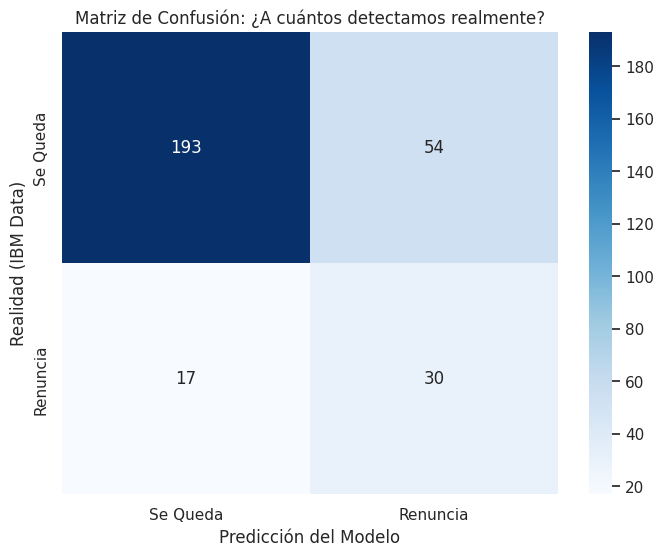

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. El modelo hace sus predicciones sobre los datos que jamás ha visto
y_pred = modelo_logistico_2.predict(X_test_scaled) # lista de "Sí" o "No
y_proba = modelo_logistico_2.predict_proba(X_test_scaled)[:, 1] # A diferencia de la anterior, esta no da un 0 o 1, sino que da probabilidad exacta (ej. 0.87 o 0.12)
                                                                # La función devuelve dos columnas: la probabilidad de que NO renuncie y la probabilidad de que SÍ renuncie.
                                                                # Al poner [:, 1], pedimos todas las filas y solo la segunda columna (la probabilidad de que renuncia).
# 2. Cálculo de métricas
print("--- REPORTE DE CLASIFICACIÓN ---")
# Aquí se verán Accuracy, Precision, Recall y F1-Score
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Final en Test: {roc_auc_score(y_test, y_proba):.4f}")

# 3. Visualización de la Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se Queda', 'Renuncia'],
            yticklabels=['Se Queda', 'Renuncia'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (IBM Data)')
plt.title('Matriz de Confusión: ¿A cuántos detectamos realmente?')
plt.show()

**Evaluación de Métricas y Viabilidad del Modelo**

**Rendimiento General (ROC-AUC: 0.7958):** El modelo presenta una métrica de área bajo la curva cercana al 80%, lo que indica una alta capacidad para distinguir entre un empleado que permanecerá en la empresa y uno con intención de renunciar. La cercanía entre el resultado de validación ($0.82$) y el de prueba ($0.79$) confirma que el modelo no padece de sobreentrenamiento (overfitting) y es capaz de generalizar sus predicciones a nuevos datos.

**Capacidad de Detección (Recall Clase 1: $0.64$):** El modelo prioriza la sensibilidad, logrando identificar correctamente al 64% de los casos reales de rotación. En el contexto de IBM, esto significa que la empresa puede actuar preventivamente sobre la mayoría de los colaboradores en riesgo.

**Viabilidad Estratégica:** Aunque la precisión es moderada ($0.36$), el modelo es altamente viable desde una perspectiva de negocio. En la gestión de talento, el costo de omitir una renuncia inminente (pérdida de conocimiento, costos de reclutamiento) es significativamente mayor al costo de una falsa alarma (una entrevista de retención con un empleado que no planeaba irse). Por lo tanto, el modelo cumple con el objetivo de ser una herramienta de alerta temprana eficiente.


**Análisis de la Matriz de Confusión**

La matriz de confusión permite visualizar el comportamiento del modelo frente a los 294 casos del set de prueba, desglosando los aciertos y tipos de error.

**Aciertos (Verdaderos Positivos y Negativos):**

El modelo identificó con éxito a 194 empleados que decidieron quedarse (Verdaderos Negativos), manteniendo una base sólida de predicción sobre la estabilidad.

Se detectaron correctamente 30 casos de renuncia (Verdaderos Positivos), los cuales representan oportunidades directas de intervención para RR.HH.

**Análisis de Errores (Falsos Positivos y Negativos):**

**Falsos Positivos (53 casos):**

Representan empleados que el modelo marcó con riesgo de salida pero que se mantuvieron en la empresa. Estas "falsas alarmas" son el resultado de la configuración **balanced** del modelo para no ignorar a la minoría que renuncia.

**Falsos Negativos (17 casos):**

Son renuncias que el modelo no pudo predecir. Representan el margen de error donde factores no medidos en el dataset (motivos personales externos, por ejemplo) influyeron en la decisión del colaborador.

**Conclusión Visual:** La concentración de datos en la diagonal de la matriz y la capacidad de capturar más de la mitad de las renuncias reales confirman que el modelo es una herramienta robusta. La visualización mediante el mapa de calor permite a los tomadores de decisiones comprender que, aunque el modelo es precavido, su enfoque está alineado con la retención proactiva de talento.

------------------------------------------------

**Descubrimiento de las causas**

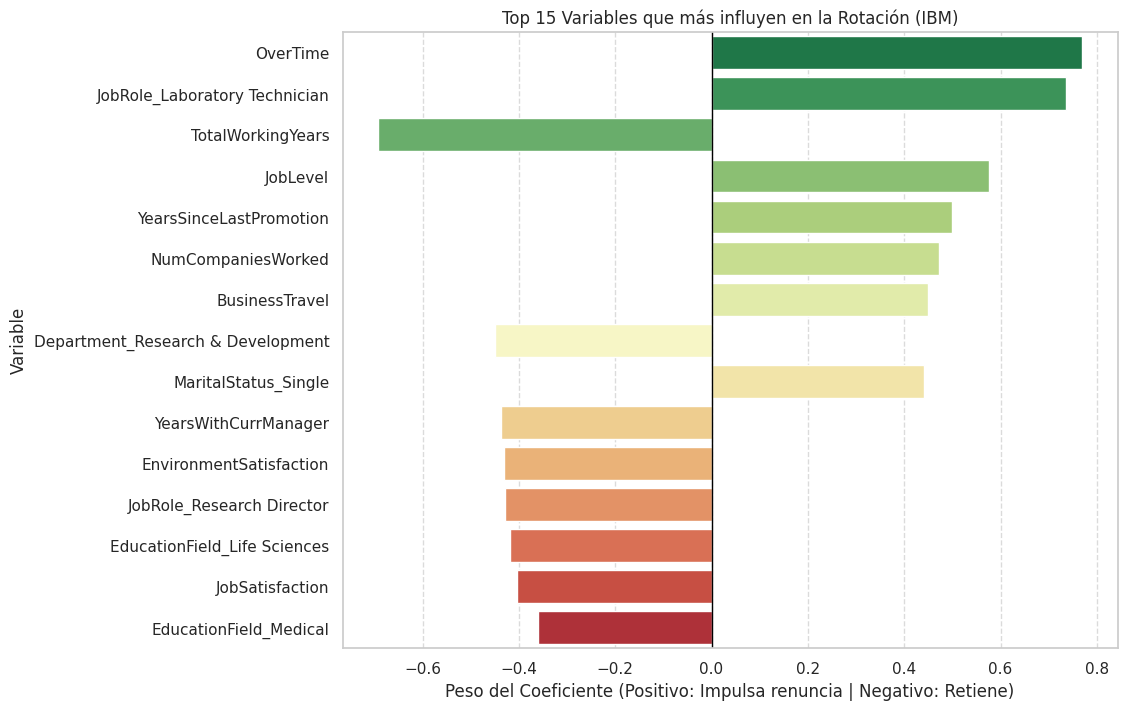

In [40]:
# El modelo ha establecido un peso (coeficiente) a cada una de las 41 variables.
# Coeficiente Positivo: A medida que esta variable aumenta, aumenta la probabilidad de que el empleado renuncie (las Horas Extra quizá).
# Coeficiente Negativo: A medida que esta variable aumenta, disminuye la probabilidad de renuncia (el Sueldo).

# 1. Primero es necesario extraer los coeficientes antes mencionados
# Usamos .ravel() para convertir la matriz de coeficientes en una lista plana
coeficientes = modelo_logistico_2.coef_.ravel()

# 2. Crear un DataFrame para asociar cada variable con su peso
importancia_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': coeficientes
})

# 3. Se calcula el valor absoluto para saber qué variables "mueven más la aguja" independientemente de si es para bien o para mal
importancia_df['Absoluto'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Absoluto', ascending=False)

# 4. Visualización del Top 15 variables más influyentes
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coeficiente',
    y='Variable',
    data=importancia_df.head(15),
    palette='RdYlGn_r',
    hue='Variable',  # Asignamos la variable al color
    legend=False     # Quitamos la leyenda porque es redundante
)

plt.title('Top 15 Variables que más influyen en la Rotación (IBM)')
plt.xlabel('Peso del Coeficiente (Positivo: Impulsa renuncia | Negativo: Retiene)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Añadimos una línea en el 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [45]:
# como complemento del visual:
importancia_df.sort_values(by='Absoluto', ascending=False).head(15)

,Variable,Coeficiente,Absoluto
13,OverTime,0.769714,0.769714
32,JobRole_Laboratory Technician,0.736213,0.736213
18,TotalWorkingYears,-0.693022,0.693022
9,JobLevel,0.575755,0.575755
23,YearsSinceLastPromotion,0.498753,0.498753
12,NumCompaniesWorked,0.472063,0.472063
1,BusinessTravel,0.449797,0.449797
25,Department_Research & Development,-0.449577,0.449577
39,MaritalStatus_Single,0.440637,0.440637
24,YearsWithCurrManager,-0.437897,0.437897


**TOP 3 Variables que impulsan la rotación**

**1.- OverTime (Horas Extra):** Es el predictor más fuerte de renuncia. Indica un agotamiento del colaborador. Cuando el balance vida-trabajo se rompe de forma constante, la probabilidad de salida aumenta fuertemente, independientemente de otros beneficios.

**2.- JobRole_Laboratory Technician:** Este rol específico presenta una vulnerabilidad crítica. Ser técnico de laboratorio en IBM está asociado con una mayor rotación, lo que sugiere condiciones laborales, niveles de estrés o una oferta de mercado externa que supera las condiciones actuales para este puesto.

**3.- JobLevel (Nivel del Puesto):** Curiosamente, en este modelo, el nivel del puesto actúa como un impulsor de salida. Esto suele suceder cuando los empleados en niveles medios sienten que han alcanzado un techo o cuando las responsabilidades del nivel no son proporcionales a las recompensas percibidas.


**TOP 3 Variables que fomentan la retención**

**1.- TotalWorkingYears (Experiencia Acumulada):** El factor de retención más sólido. Los empleados con trayectorias profesionales más largas (seniority) muestran un compromiso mayor. La madurez profesional se traduce en estabilidad para la organización.

**2.- Department_Research & Development:** Pertenecer a esta área específica actúa como un escudo contra la rotación. Es probable que la naturaleza del trabajo, el prestigio o la cultura interna de este departamento generen un sentido de pertenencia superior al resto de la empresa.

**3.- YearsWithCurrManager (Estabilidad con el Líder):** Un coeficiente negativo relevante. La continuidad bajo un mismo mando reduce la intención de renuncia. Esto valida la premisa de que una relación sólida y predecible con el jefe directo es fundamental para retener al personal.

**Recomendaciones para el departamento de RR.HH**

Basado en los resultados de modelo_logistico_2 se recomienda realizar las acciones:

**1. Auditoría y Mitigación del Overtime**

**Acción:** Revisar las cargas de trabajo en los departamentos con mayores índices de horas extra y establecer un tope máximo mensual.

**Porqué:** El modelo identifica las horas extra como el principal detonante de renuncia. Reducir esta carga no es solo un tema de bienestar, sino una estrategia financiera para evitar los altos costos de sustitución de personal por burnout.

**2. Programa de Intervención para Técnicos de Laboratorio**

**Acción:** Realizar entrevistas de salida y encuestas de clima específicas para este rol, además de revisar su competitividad salarial frente al mercado.

**Porqué:** Los datos señalan este puesto como un punto de fuga específico. Ignorar esta alerta segmentada resultará en una pérdida constante de capital humano técnico difícil de reemplazar.

**3. Revisión de Planes de Carrera y Promociones**

**Acción:** Implementar revisiones de desempeño más frecuentes y planes de promoción interna claros, especialmente para quienes llevan más de 2 o 3 años en el mismo nivel.

**Porqué:** La variable YearsSinceLastPromotion también mostró un impacto positivo en la renuncia. El estancamiento percibido es un "enemigo silencioso" de la retención; el empleado necesita sentir que su carrera avanza al ritmo de su esfuerzo.

**4. Fortalecimiento del Liderazgo Intermedio**

**Acción:** Capacitar a los mánagers en habilidades de retención y fomentar la estabilidad de los equipos bajo un mismo líder cuando sea posible.

**Porqué:** Dado que la permanencia con el mismo mánager retiene a la gente, es vital asegurar que esos líderes tengan las herramientas para mantener un clima saludable, pues son ellos quienes ejecutan la retención en el día a día.

-----------------------------------------------------